# Results on the MHAR 5-min Feature Set

This notebook starts by loading and aligning the saved out-of-sample realized-volatility forecasts for all MHAR models into one common evaluation panel.

## 1. Imports and Paths

Defining the forecast directories and importing the packages needed to construct the unified forecast panel.

In [288]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import display

plt.style.use("default")

benchmark_dir = Path("/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MHAR/Benchmark Models")
regularized_dir = Path("/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MHAR/Regularized Linear Models")
tree_dir = Path("/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MHAR/Tree-based Models")
nn_dir = Path("/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MHAR/Neural Networks/New Neural Networks with Extended Update")

## 2. Load and Align Forecasts

The saved forecast files are not fully uniform across model classes. Most models store the date index as `Unnamed: 0` and the forecast as `RV_forecast`, while the neural-network files store `Date` together with both `RV_forecast_best` and `RV_forecast_top10`. The code below standardizes those formats and creates one merged data frame with the date, realized volatility, and one forecast column per model.

In [291]:
model_specs = [
    {"display_name": "HAR", "file_path": benchmark_dir / "forecasts_HAR.csv", "forecast_column": "RV_forecast"},
    {"display_name": "HAR-X", "file_path": benchmark_dir / "forecasts_HARX.csv", "forecast_column": "RV_forecast"},
    {"display_name": "LogHAR", "file_path": benchmark_dir / "forecasts_LogHAR.csv", "forecast_column": "RV_forecast"},
    {"display_name": "LevHAR", "file_path": benchmark_dir / "forecasts_LevHAR.csv", "forecast_column": "RV_forecast"},
    {"display_name": "SHAR", "file_path": benchmark_dir / "forecasts_SHAR.csv", "forecast_column": "RV_forecast"},
    {"display_name": "HARQ", "file_path": benchmark_dir / "forecasts_HARQ.csv", "forecast_column": "RV_forecast"},
    {"display_name": "RR", "file_path": regularized_dir / "forecasts_RR.csv", "forecast_column": "RV_forecast"},
    {"display_name": "LA", "file_path": regularized_dir / "forecasts_LA.csv", "forecast_column": "RV_forecast"},
    {"display_name": "EN", "file_path": regularized_dir / "forecasts_EN.csv", "forecast_column": "RV_forecast"},
    {"display_name": "BG", "file_path": tree_dir / "forecasts_BG.csv", "forecast_column": "RV_forecast"},
    {"display_name": "RF", "file_path": tree_dir / "forecasts_RF.csv", "forecast_column": "RV_forecast"},
    {"display_name": "GB", "file_path": tree_dir / "forecasts_GB.csv", "forecast_column": "RV_forecast"},
    {"display_name": "NN1_best", "file_path": nn_dir / "forecast_NN1.csv", "forecast_column": "RV_forecast_best"},
    {"display_name": "NN1_top10", "file_path": nn_dir / "forecast_NN1.csv", "forecast_column": "RV_forecast_top10"},
    {"display_name": "NN2_best", "file_path": nn_dir / "forecast_NN2.csv", "forecast_column": "RV_forecast_best"},
    {"display_name": "NN2_top10", "file_path": nn_dir / "forecast_NN2.csv", "forecast_column": "RV_forecast_top10"},
    {"display_name": "NN3_best", "file_path": nn_dir / "forecast_NN3.csv", "forecast_column": "RV_forecast_best"},
    {"display_name": "NN3_top10", "file_path": nn_dir / "forecast_NN3.csv", "forecast_column": "RV_forecast_top10"},
    {"display_name": "NN4_best", "file_path": nn_dir / "forecast_NN4.csv", "forecast_column": "RV_forecast_best"},
    {"display_name": "NN4_top10", "file_path": nn_dir / "forecast_NN4.csv", "forecast_column": "RV_forecast_top10"},
]

model_order = [spec["display_name"] for spec in model_specs]


def load_forecast_series(file_path: Path, forecast_column: str, display_name: str) -> pd.DataFrame:
    df = pd.read_csv(file_path)

    if "Date" in df.columns:
        date_column = "Date"
    elif "Unnamed: 0" in df.columns:
        date_column = "Unnamed: 0"
    else:
        raise ValueError(f"No recognized date column found in {file_path}")

    required_columns = [date_column, "RV_actual", forecast_column]
    missing_columns = [column for column in required_columns if column not in df.columns]
    if missing_columns:
        raise ValueError(f"Missing columns {missing_columns} in {file_path}")

    df = df[required_columns].copy()
    df[date_column] = pd.to_datetime(df[date_column])
    df = df.rename(columns={date_column: "Date", forecast_column: display_name})
    return df.sort_values("Date").reset_index(drop=True)


actual_panel = None
forecast_panel = None

for spec in model_specs:
    model_df = load_forecast_series(
        file_path=spec["file_path"],
        forecast_column=spec["forecast_column"],
        display_name=spec["display_name"],
    )

    if actual_panel is None:
        actual_panel = model_df[["Date", "RV_actual"]].copy()
        forecast_panel = actual_panel.copy()
    else:
        actual_check = actual_panel.merge(
            model_df[["Date", "RV_actual"]],
            on="Date",
            how="inner",
            suffixes=("_baseline", "_candidate"),
        )
        if not np.allclose(
            actual_check["RV_actual_baseline"],
            actual_check["RV_actual_candidate"],
            equal_nan=True,
        ):
            raise ValueError(f"RV_actual does not align for {spec['display_name']}")

    forecast_panel = forecast_panel.merge(
        model_df[["Date", spec["display_name"]]],
        on="Date",
        how="inner",
    )

forecast_panel = forecast_panel[["Date", "RV_actual", *model_order]].sort_values("Date").reset_index(drop=True)
available_models = [model for model in model_order if model in forecast_panel.columns]
actual = forecast_panel["RV_actual"]

print(f"Common evaluation sample: {len(forecast_panel)} observations")
print(f"Evaluation period: {forecast_panel['Date'].min().date()} to {forecast_panel['Date'].max().date()}")
print(f"Number of forecast columns: {len(available_models)}")

display(forecast_panel.head())

Common evaluation sample: 1099 observations
Evaluation period: 2016-04-21 to 2020-08-06
Number of forecast columns: 20


,Date,RV_actual,HAR,HAR-X,LogHAR,LevHAR,SHAR,HARQ,RR,LA,...,RF,GB,NN1_best,NN1_top10,NN2_best,NN2_top10,NN3_best,NN3_top10,NN4_best,NN4_top10
0,2016-04-21,0.000053,0.000101,0.000101,0.000098,0.000053,0.000099,0.000104,0.000105,0.000103,...,0.000093,0.000099,0.000109,0.000106,0.000100,0.000095,0.000092,0.000097,0.000090,0.000099
1,2016-04-22,0.000081,0.000085,0.000085,0.000080,0.000065,0.000087,0.000070,0.000090,0.000089,...,0.000073,0.000089,0.000082,0.000084,0.000086,0.000086,0.000088,0.000086,0.000083,0.000089
2,2016-04-25,0.000066,0.000090,0.000090,0.000087,0.000081,0.000092,0.000085,0.000094,0.000093,...,0.000091,0.000094,0.000091,0.000093,0.000091,0.000089,0.000089,0.000090,0.000085,0.000092
3,2016-04-26,0.000059,0.000087,0.000087,0.000084,0.000058,0.000088,0.000077,0.000091,0.000091,...,0.000086,0.000095,0.000085,0.000088,0.000088,0.000088,0.000088,0.000088,0.000084,0.000090
4,2016-04-27,0.000097,0.000084,0.000084,0.000080,0.000068,0.000085,0.000072,0.000088,0.000088,...,0.000072,0.000088,0.000081,0.000085,0.000085,0.000086,0.000087,0.000086,0.000082,0.000088


## 3. Model Ranking by MSE

The table below ranks all MHAR models by their out-of-sample mean squared error (MSE) on the common evaluation sample. To improve readability, the reported values are scaled by $10^{-8}$, so a displayed value of `5.66` corresponds to an MSE of $5.66 \times 10^{-8}$. Note that on the MHAR feature set HAR-X has no exogenous regressors available, so by construction it collapses to the standard HAR specification and reports an identical out-of-sample MSE.

In [294]:
mse_display_map = {
    "HAR": "HAR",
    "HAR-X": "HAR-X",
    "LogHAR": "LogHAR",
    "LevHAR": "LevHAR",
    "SHAR": "SHAR",
    "HARQ": "HARQ",
    "RR": "RR",
    "LA": "LA",
    "EN": "EN",
    "BG": "BG",
    "RF": "RF",
    "GB": "GB",
    "NN1_best": "$\\mathbf{NN}_{1}^{1}$",
    "NN1_top10": "$\\mathbf{NN}_{1}^{10}$",
    "NN2_best": "$\\mathbf{NN}_{2}^{1}$",
    "NN2_top10": "$\\mathbf{NN}_{2}^{10}$",
    "NN3_best": "$\\mathbf{NN}_{3}^{1}$",
    "NN3_top10": "$\\mathbf{NN}_{3}^{10}$",
    "NN4_best": "$\\mathbf{NN}_{4}^{1}$",
    "NN4_top10": "$\\mathbf{NN}_{4}^{10}$",
}

mse_by_model = {
    model: float(np.mean((actual - forecast_panel[model]) ** 2))
    for model in available_models
}

mse_ranking = (
    pd.DataFrame.from_dict(mse_by_model, orient="index", columns=["MSE"])
    .rename(index=mse_display_map)
    .assign(MSE=lambda df: df["MSE"] * 1e8)
    .sort_values("MSE", ascending=True)
)

mse_ranking_styler = (
    mse_ranking.style.format({"MSE": "{:.2f}"})
    .set_caption("Table: Out-of-sample MSE ranking for the MHAR feature set (values reported in 10^-8 units)")
    .set_table_styles(
        [
            {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold"), ("text-align", "left"), ("padding-bottom", "8px")]},
            {"selector": "thead th", "props": [("font-size", "12px"), ("text-align", "center"), ("border-bottom", "1px solid black"), ("padding", "6px")]},
            {"selector": "tbody th", "props": [("font-size", "12px"), ("text-align", "left"), ("padding", "6px"), ("font-weight", "bold")]},
            {"selector": "tbody td", "props": [("font-size", "12px"), ("text-align", "center"), ("padding", "6px")]},
            {"selector": "table", "props": [("border-collapse", "collapse"), ("width", "100%")]},
        ]
    )
)

display(mse_ranking_styler)

,MSE
HARQ,4.79
RF,5.19
LogHAR,5.30
BG,5.33
LevHAR,5.39
$\mathbf{NN}_{1}^{1}$,5.47
GB,5.51
$\mathbf{NN}_{2}^{1}$,5.63
$\mathbf{NN}_{2}^{10}$,5.65
HAR,5.66


## 4. Summary of Loss Functions

Using the common evaluation panel from section 2, the figure below summarizes four out-of-sample loss functions for each MHAR model. Let $RV_t$ denote realized volatility, let $\widehat{RV}_{i,t}$ denote the forecast from model $i$ at time $t$, and define the forecast error as $e_{i,t} = RV_t - \widehat{RV}_{i,t}$ for $t = 1, \ldots, T$. Each subplot is sorted independently in ascending order from left to right, so lower bars correspond to better forecast performance under that loss function.

$$
\mathrm{MSE}_i = \frac{1}{T} \sum_{t=1}^{T} e_{i,t}^2
$$

$$
\mathrm{QLIKE}_i = \frac{1}{T} \sum_{t=1}^{T} \left( \frac{RV_t}{\widehat{RV}_{i,t}} - \log\!\left(\frac{RV_t}{\widehat{RV}_{i,t}}\right) - 1 \right)
$$

$$
\mathrm{MAE}_i = \frac{1}{T} \sum_{t=1}^{T} |e_{i,t}|
$$

$$
\mathrm{RMSE}_i = \sqrt{\frac{1}{T} \sum_{t=1}^{T} e_{i,t}^2} = \sqrt{\mathrm{MSE}_i}
$$

The QLIKE specification follows the normalized form used in Bollerslev, Patton, and Quaedvlieg (2016, *Journal of Econometrics*) and is theoretically motivated by Patton (2011, *Journal of Econometrics*), who shows that QLIKE belongs to the family of loss functions that yield consistent forecast rankings even when the volatility proxy is noisy. The constant $-\log RV_t - 1$ pins the loss at zero whenever the forecast equals the realization, but does not affect any pairwise loss differential between two competing models. Hence ranking under this normalization is equivalent to ranking under the textbook Patton (2011) form $L^{\mathrm{P}}(\sigma^2, h) = \log h + \sigma^2/h$.

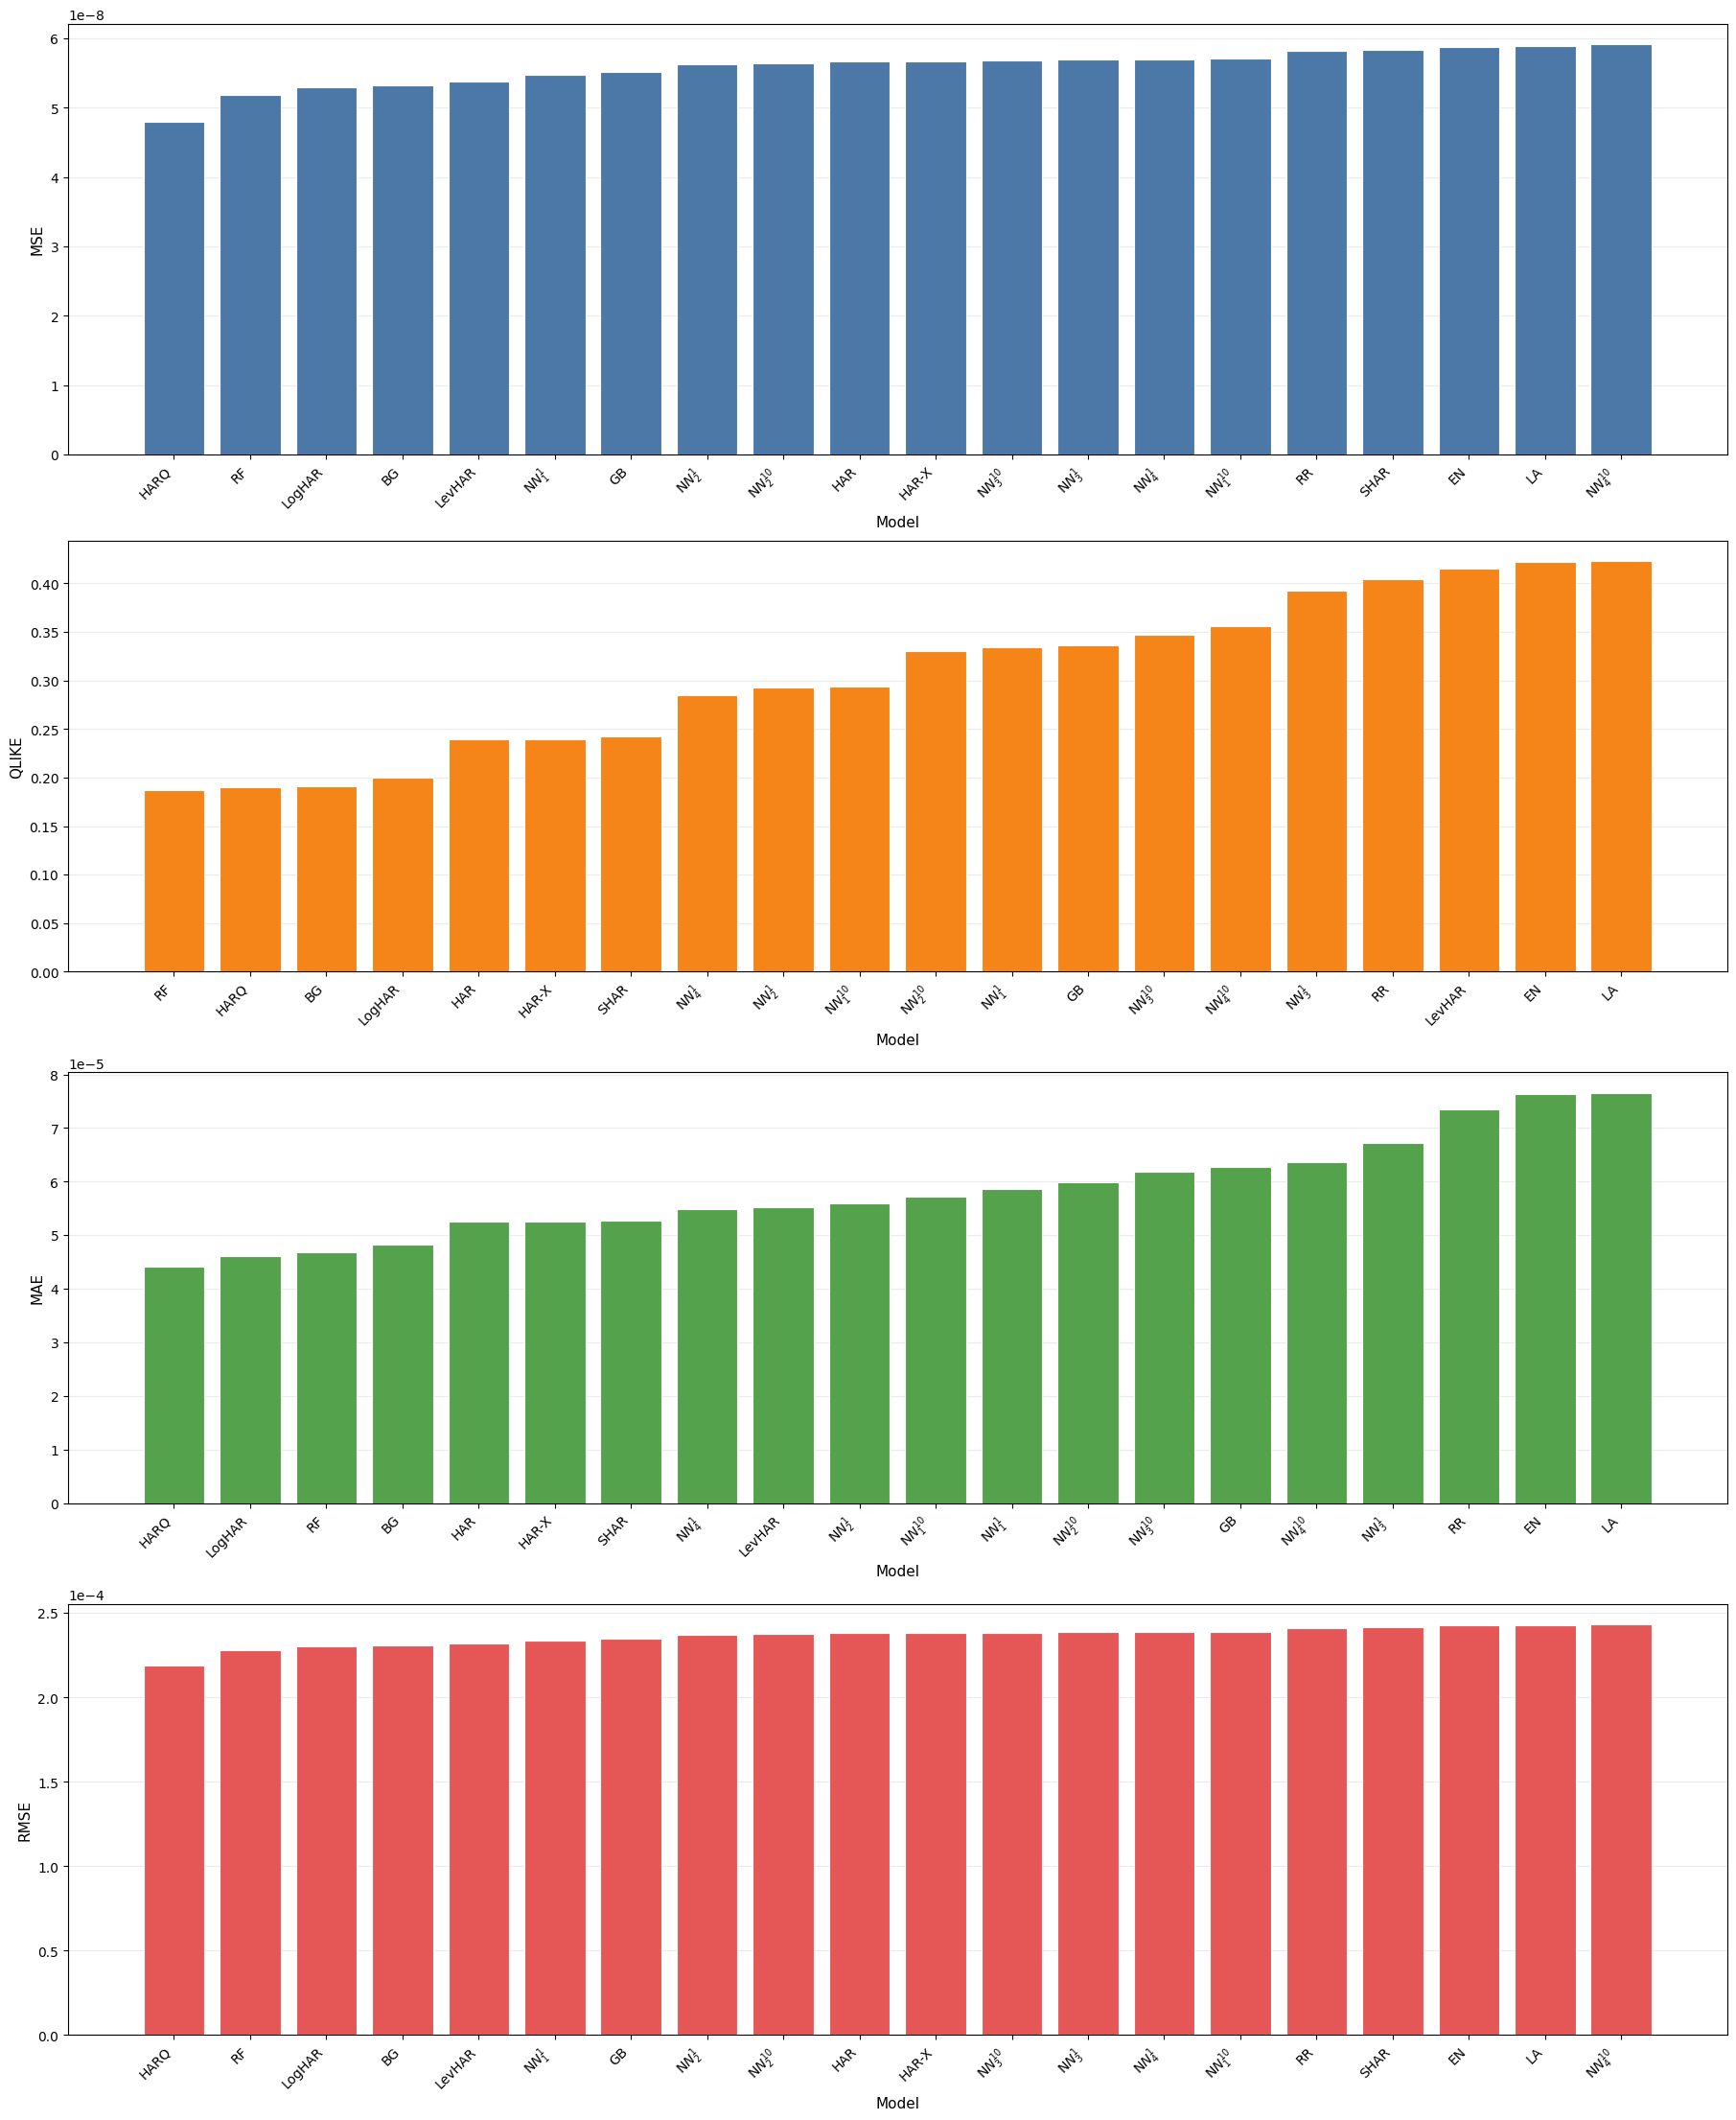

In [297]:
if (actual <= 0).any():
    raise ValueError("QLIKE requires strictly positive realized volatility values.")

loss_summary = []

for model in available_models:
    forecast = forecast_panel[model]
    if (forecast <= 0).any():
        raise ValueError(f"QLIKE requires strictly positive forecasts for {model}.")

    error = actual - forecast
    loss_summary.append(
        {
            "Model": model,
            "MSE": np.mean(error**2),
            "QLIKE": np.mean((actual / forecast) - np.log(actual / forecast) - 1),
            "MAE": np.mean(np.abs(error)),
        }
    )

loss_summary = pd.DataFrame(loss_summary).set_index("Model").loc[available_models]
loss_summary["RMSE"] = np.sqrt(loss_summary["MSE"])

loss_plot_label_map = {
    "HAR": "HAR",
    "HAR-X": "HAR-X",
    "LogHAR": "LogHAR",
    "LevHAR": "LevHAR",
    "SHAR": "SHAR",
    "HARQ": "HARQ",
    "RR": "RR",
    "LA": "LA",
    "EN": "EN",
    "BG": "BG",
    "RF": "RF",
    "GB": "GB",
    "NN1_best": r"N$N_{1}^{1}$",
    "NN1_top10": r"N$N_{1}^{10}$",
    "NN2_best": r"N$N_{2}^{1}$",
    "NN2_top10": r"N$N_{2}^{10}$",
    "NN3_best": r"N$N_{3}^{1}$",
    "NN3_top10": r"N$N_{3}^{10}$",
    "NN4_best": r"N$N_{4}^{1}$",
    "NN4_top10": r"N$N_{4}^{10}$",
}

plot_specs = [
    ("MSE", "#4C78A8"),
    ("QLIKE", "#F58518"),
    ("MAE", "#54A24B"),
    ("RMSE", "#E45756"),
]

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(18, 22), constrained_layout=True)

for ax, (metric, color) in zip(axes, plot_specs):
    ranked_loss = loss_summary.sort_values(by=metric, kind="stable")
    display_labels = [loss_plot_label_map.get(model, model) for model in ranked_loss.index]
    ax.bar(display_labels, ranked_loss[metric], color=color, edgecolor="white", linewidth=0.8)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_xlabel("Model", fontsize=11)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.tick_params(axis="x", rotation=45, labelsize=10)
    for label in ax.get_xticklabels():
        label.set_ha("right")
    if metric in {"MSE", "MAE", "RMSE"}:
        ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
plt.show()

## 5. Pairwise Relative MSE and Diebold--Mariano Test

This table is a **single-index adaptation** of the pairwise relative-MSE comparison in Christensen et al. (2023). In the paper, each entry is a cross-sectional average across many stock-level forecast comparisons, and the significance markers summarize how often the one-sided Diebold--Mariano null is rejected across those individual assets. Here, we only have one forecast-error time series for the EURO STOXX 50 index, so each entry reports the relative MSE for that single index together with a one-sided time-series Diebold--Mariano test. Recall further that on the MHAR feature set HAR-X coincides with HAR by construction, so the corresponding row and column are mechanically identical.

For each ordered model pair $(i, j)$, let $e_{i,t} = RV_t - \widehat{RV}_{i,t}$ and define the loss differential as $d_{ij,t} = e_{i,t}^2 - e_{j,t}^2$. We test the null hypothesis $H_0: \mathbb{E}[d_{ij,t}] = 0$ against the one-sided alternative $H_1: \mathbb{E}[d_{ij,t}] > 0$, so rejection implies that the **column** model $j$ has lower squared-error loss, and hence lower MSE, than the **row** model $i$.

To align this single-index version with the paper's Diebold--Mariano convention, we use the Diebold--Mariano (1995) statistic with **Newey--West (1987) standard errors**, **Bartlett kernel weights**, and a fixed **truncation lag of $L = 5$**:

$$
\widehat{S}^{\mathrm{NW}}_{ij}(0) = \widehat{\gamma}_{ij}(0) + 2 \sum_{\ell=1}^{L} \left(1 - \frac{\ell}{L+1}\right) \widehat{\gamma}_{ij}(\ell),
\qquad
L = 5,
$$

$$
DM_{ij}^{\mathrm{NW}} = \frac{\bar d_{ij}}{\sqrt{\widehat{S}^{\mathrm{NW}}_{ij}(0) / T}}.
$$

For one-step-ahead forecasts the optimal forecast-error process is at most an MA$(h-1)$ with $h=1$, so a lag of zero would be theoretically sufficient. We nevertheless retain $L = 5$ as a conservative HAC choice that absorbs residual serial correlation arising from model misspecification; this lag length is in line with the Newey and West (1994) automatic bandwidth rule $L = \lfloor 4 (T/100)^{2/9} \rfloor \approx 6$ for our $T = 1{,}099$ test sample, and matches common practice in the realized-variance forecasting literature (e.g. Patton and Sheppard 2009). Given $T \approx 1{,}100$, the Harvey, Leybourne, and Newbold (1997) small-sample correction yields a multiplicative factor of $\sqrt{T/T} \approx 1$ and a $t_{T-1}$ critical value indistinguishable from the standard normal, so we report $p$-values from $\mathcal{N}(0,1)$ in the table below.

In [300]:
display_label_map = {
    "HAR": "HAR",
    "HAR-X": "HAR-X",
    "LogHAR": "LogHAR",
    "LevHAR": "LevHAR",
    "SHAR": "SHAR",
    "HARQ": "HARQ",
    "RR": "RR",
    "LA": "LA",
    "EN": "EN",
    "BG": "BG",
    "RF": "RF",
    "GB": "GB",
    "NN1_best": "$\\mathbf{NN}_{1}^{1}$",
    "NN1_top10": "$\\mathbf{NN}_{1}^{10}$",
    "NN2_best": "$\\mathbf{NN}_{2}^{1}$",
    "NN2_top10": "$\\mathbf{NN}_{2}^{10}$",
    "NN3_best": "$\\mathbf{NN}_{3}^{1}$",
    "NN3_top10": "$\\mathbf{NN}_{3}^{10}$",
    "NN4_best": "$\\mathbf{NN}_{4}^{1}$",
    "NN4_top10": "$\\mathbf{NN}_{4}^{10}$",
}


def dm_test_one_sided_newey_west(actual: pd.Series, forecast_i: pd.Series, forecast_j: pd.Series, max_lag: int = 5):
    aligned = pd.concat([actual, forecast_i, forecast_j], axis=1).dropna()
    y = aligned.iloc[:, 0].to_numpy(dtype=float)
    f_i = aligned.iloc[:, 1].to_numpy(dtype=float)
    f_j = aligned.iloc[:, 2].to_numpy(dtype=float)

    d = (y - f_i) ** 2 - (y - f_j) ** 2
    T = len(d)
    if T < 5:
        return np.nan, np.nan

    mean_d = float(d.mean())
    centered = d - mean_d

    lag_count = min(max_lag, T - 1)
    gamma_0 = float(np.mean(centered * centered))
    long_run_var = gamma_0

    for lag in range(1, lag_count + 1):
        gamma_lag = float(np.mean(centered[lag:] * centered[:-lag]))
        bartlett_weight = 1.0 - lag / (lag_count + 1)
        long_run_var += 2.0 * bartlett_weight * gamma_lag

    if long_run_var <= 1e-20:
        if abs(mean_d) <= 1e-20:
            return mean_d, 1.0
        return mean_d, 0.0 if mean_d > 0 else 1.0

    dm_stat = mean_d / np.sqrt(long_run_var / T)
    p_value = float(1 - stats.norm.cdf(dm_stat))
    return mean_d, p_value


def star_label(p_value: float) -> str:
    if pd.isna(p_value):
        return ""
    if p_value < 0.01:
        return "***"
    if p_value < 0.05:
        return "**"
    if p_value < 0.10:
        return "*"
    return ""


mse_by_model = {
    model: float(np.mean((actual - forecast_panel[model]) ** 2))
    for model in available_models
}

relative_mse_matrix = pd.DataFrame(index=available_models, columns=available_models, dtype=float)
dm_pvalue_matrix = pd.DataFrame(index=available_models, columns=available_models, dtype=float)
pairwise_relative_mse_table = pd.DataFrame(index=available_models, columns=available_models, dtype=object)

for row_model in available_models:
    for col_model in available_models:
        if row_model == col_model:
            relative_mse_matrix.loc[row_model, col_model] = np.nan
            dm_pvalue_matrix.loc[row_model, col_model] = np.nan
            pairwise_relative_mse_table.loc[row_model, col_model] = "-"
            continue

        rel_mse = mse_by_model[col_model] / mse_by_model[row_model]
        _, p_value = dm_test_one_sided_newey_west(actual, forecast_panel[row_model], forecast_panel[col_model], max_lag=5)

        relative_mse_matrix.loc[row_model, col_model] = rel_mse
        dm_pvalue_matrix.loc[row_model, col_model] = p_value
        pairwise_relative_mse_table.loc[row_model, col_model] = f"{rel_mse:.3f}{star_label(p_value)}"

pairwise_relative_mse_display = pairwise_relative_mse_table.rename(index=display_label_map, columns=display_label_map)

styled_relative_mse = (
    pairwise_relative_mse_display.style
    .set_caption("Table: Single-index pairwise relative MSE and Diebold-Mariano test for the MHAR feature set")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold"), ("text-align", "left"), ("padding-bottom", "8px")]},
        {"selector": "thead th", "props": [("font-size", "12px"), ("text-align", "center"), ("border-bottom", "1px solid black"), ("padding", "6px")]},
        {"selector": "tbody th", "props": [("font-size", "12px"), ("text-align", "left"), ("padding", "6px"), ("font-weight", "bold")]},
        {"selector": "tbody td", "props": [("font-size", "12px"), ("text-align", "center"), ("padding", "6px")]},
        {"selector": "table", "props": [("border-collapse", "collapse"), ("width", "100%")]},
    ])
)

display(styled_relative_mse)

,HAR,HAR-X,LogHAR,LevHAR,SHAR,HARQ,RR,LA,EN,BG,RF,GB,$\mathbf{NN}_{1}^{1}$,$\mathbf{NN}_{1}^{10}$,$\mathbf{NN}_{2}^{1}$,$\mathbf{NN}_{2}^{10}$,$\mathbf{NN}_{3}^{1}$,$\mathbf{NN}_{3}^{10}$,$\mathbf{NN}_{4}^{1}$,$\mathbf{NN}_{4}^{10}$
HAR,-,1.000,0.936*,0.951,1.031,0.846*,1.028,1.039,1.039,0.941,0.916,0.973,0.966,1.009,0.994,0.997,1.005,1.003,1.006,1.045
HAR-X,1.000,-,0.936*,0.951,1.031,0.846*,1.028,1.039,1.039,0.941,0.916,0.973,0.966,1.009,0.994,0.997,1.005,1.003,1.006,1.045
LogHAR,1.068,1.068,-,1.016,1.101,0.904*,1.098,1.110,1.110,1.005,0.979,1.040,1.032,1.078,1.062,1.065,1.074,1.072,1.075,1.117
LevHAR,1.052,1.052,0.984,-,1.084,0.890*,1.081,1.093,1.093,0.989,0.964,1.024,1.016,1.061,1.046,1.048,1.057,1.055,1.058,1.099
SHAR,0.970,0.970,0.908,0.922,-,0.821*,0.997,1.008,1.008,0.913,0.889,0.944,0.937,0.979,0.965,0.967,0.975,0.973,0.976,1.014
HARQ,1.182,1.182,1.106,1.124,1.218,-,1.215,1.228,1.228,1.112,1.083,1.150,1.141,1.192,1.175,1.178,1.188,1.186,1.189,1.235
RR,0.973,0.973,0.911***,0.925,1.003,0.823**,-,1.011,1.011,0.915,0.892*,0.947,0.940**,0.982,0.967,0.970,0.978,0.976,0.979,1.017
LA,0.962**,0.962**,0.901***,0.915,0.992,0.814**,0.989**,-,1.000,0.905,0.882*,0.937*,0.929**,0.971,0.957,0.959,0.967,0.966,0.968,1.006
EN,0.963**,0.963**,0.901***,0.915,0.992,0.815**,0.989**,1.000,-,0.905,0.882*,0.937*,0.930**,0.971,0.957,0.960,0.968,0.966,0.969,1.006
BG,1.063,1.063,0.995,1.011,1.096,0.900*,1.093,1.105,1.104,-,0.974,1.035,1.027,1.072,1.057,1.060,1.069,1.067,1.070,1.111


**Notes:** Each entry reports the out-of-sample realized-variance forecast MSE of the selected column model relative to the selected row model. Values below `1.000` indicate that the column model has a lower MSE than the row model. The significance markers are based on a one-sided Diebold--Mariano (1995) test under squared-error loss with Newey--West standard errors, 5 lags, and Bartlett weights. Because this notebook applies the comparison to a single EURO STOXX 50 time series, the stars should be interpreted as time-series test results rather than the paper's cross-sectional significance summary across many assets.

## 6. Pairwise Relative QLIKE and Diebold--Mariano Test

This section repeats the **exact same single-index adaptation** and **exact same one-sided Diebold--Mariano procedure** as in Section 5, but replaces squared-error loss with the QLIKE loss function. Switching to QLIKE is motivated by two well-documented properties of realized-variance forecast evaluation. First, QLIKE belongs to the family of loss functions that yield consistent forecast rankings even when the volatility proxy is noisy, as established in Patton (2011, *Journal of Econometrics*). Second, because QLIKE penalizes proportional rather than absolute errors, it is substantially less sensitive to extreme realized-variance outliers than MSE -- a property emphasized by Bollerslev, Patton, and Quaedvlieg (2016, *Journal of Econometrics*) -- which is particularly relevant in our test window (2016--2020), since it includes the March 2020 COVID-19 volatility shock.

For model $i$, the period-$t$ QLIKE loss is defined as

$$
q_{i,t} = \frac{RV_t}{\widehat{RV}_{i,t}} - \log\!\left(\frac{RV_t}{\widehat{RV}_{i,t}}\right) - 1.
$$

This normalized form follows Bollerslev, Patton, and Quaedvlieg (2016) and is equivalent (up to a forecast-independent constant) to the textbook Patton (2011) formulation $L^{\mathrm{P}}(\sigma^2, h) = \log h + \sigma^2 / h$. For each ordered model pair $(i, j)$, the loss differential becomes $d_{ij,t}^{\mathrm{QLIKE}} = q_{i,t} - q_{j,t}$. We then test $H_0: \mathbb{E}[d_{ij,t}^{\mathrm{QLIKE}}] = 0$ against the one-sided alternative $H_1: \mathbb{E}[d_{ij,t}^{\mathrm{QLIKE}}] > 0$, so rejection implies that the **column** model has lower expected QLIKE loss than the **row** model. As in Section 5, the long-run variance in the Diebold--Mariano statistic is estimated using Newey--West standard errors with Bartlett weights and a truncation lag of $L = 5$, with the same justification given above.

In [304]:
def dm_test_one_sided_newey_west_from_losses(loss_i: pd.Series, loss_j: pd.Series, max_lag: int = 5):
    aligned = pd.concat([loss_i, loss_j], axis=1).dropna()
    losses_i = aligned.iloc[:, 0].to_numpy(dtype=float)
    losses_j = aligned.iloc[:, 1].to_numpy(dtype=float)

    d = losses_i - losses_j
    T = len(d)
    if T < 5:
        return np.nan, np.nan

    mean_d = float(d.mean())
    centered = d - mean_d

    lag_count = min(max_lag, T - 1)
    gamma_0 = float(np.mean(centered * centered))
    long_run_var = gamma_0

    for lag in range(1, lag_count + 1):
        gamma_lag = float(np.mean(centered[lag:] * centered[:-lag]))
        bartlett_weight = 1.0 - lag / (lag_count + 1)
        long_run_var += 2.0 * bartlett_weight * gamma_lag

    if long_run_var <= 1e-20:
        if abs(mean_d) <= 1e-20:
            return mean_d, 1.0
        return mean_d, 0.0 if mean_d > 0 else 1.0

    dm_stat = mean_d / np.sqrt(long_run_var / T)
    p_value = float(1 - stats.norm.cdf(dm_stat))
    return mean_d, p_value


qlike_loss_panel = pd.DataFrame(index=forecast_panel.index)

for model in available_models:
    forecast = forecast_panel[model]
    if (forecast <= 0).any():
        raise ValueError(f"QLIKE requires strictly positive forecasts for {model}.")
    qlike_loss_panel[model] = (actual / forecast) - np.log(actual / forecast) - 1

qlike_by_model = {
    model: float(qlike_loss_panel[model].mean())
    for model in available_models
}

relative_qlike_matrix = pd.DataFrame(index=available_models, columns=available_models, dtype=float)
dm_pvalue_matrix_qlike = pd.DataFrame(index=available_models, columns=available_models, dtype=float)
pairwise_relative_qlike_table = pd.DataFrame(index=available_models, columns=available_models, dtype=object)

for row_model in available_models:
    for col_model in available_models:
        if row_model == col_model:
            relative_qlike_matrix.loc[row_model, col_model] = np.nan
            dm_pvalue_matrix_qlike.loc[row_model, col_model] = np.nan
            pairwise_relative_qlike_table.loc[row_model, col_model] = "-"
            continue

        rel_qlike = qlike_by_model[col_model] / qlike_by_model[row_model]
        _, p_value = dm_test_one_sided_newey_west_from_losses(
            qlike_loss_panel[row_model],
            qlike_loss_panel[col_model],
            max_lag=5,
        )

        relative_qlike_matrix.loc[row_model, col_model] = rel_qlike
        dm_pvalue_matrix_qlike.loc[row_model, col_model] = p_value
        pairwise_relative_qlike_table.loc[row_model, col_model] = f"{rel_qlike:.3f}{star_label(p_value)}"

pairwise_relative_qlike_display = pairwise_relative_qlike_table.rename(index=display_label_map, columns=display_label_map)

styled_relative_qlike = (
    pairwise_relative_qlike_display.style
    .set_caption("Table: Single-index pairwise relative QLIKE and Diebold-Mariano test for the MHAR feature set")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold"), ("text-align", "left"), ("padding-bottom", "8px")]},
        {"selector": "thead th", "props": [("font-size", "12px"), ("text-align", "center"), ("border-bottom", "1px solid black"), ("padding", "6px")]},
        {"selector": "tbody th", "props": [("font-size", "12px"), ("text-align", "left"), ("padding", "6px"), ("font-weight", "bold")]},
        {"selector": "tbody td", "props": [("font-size", "12px"), ("text-align", "center"), ("padding", "6px")]},
        {"selector": "table", "props": [("border-collapse", "collapse"), ("width", "100%")]},
    ])
)

display(styled_relative_qlike)

,HAR,HAR-X,LogHAR,LevHAR,SHAR,HARQ,RR,LA,EN,BG,RF,GB,$\mathbf{NN}_{1}^{1}$,$\mathbf{NN}_{1}^{10}$,$\mathbf{NN}_{2}^{1}$,$\mathbf{NN}_{2}^{10}$,$\mathbf{NN}_{3}^{1}$,$\mathbf{NN}_{3}^{10}$,$\mathbf{NN}_{4}^{1}$,$\mathbf{NN}_{4}^{10}$
HAR,-,1.000,0.834***,1.733,1.013,0.792***,1.686,1.765,1.761,0.797***,0.781***,1.403,1.394,1.227,1.222,1.377,1.640,1.448,1.189,1.486
HAR-X,1.000,-,0.834***,1.733,1.013,0.792***,1.686,1.765,1.761,0.797***,0.781***,1.403,1.394,1.227,1.222,1.377,1.640,1.448,1.189,1.486
LogHAR,1.199,1.199,-,2.077,1.215,0.950,2.021,2.116,2.111,0.955,0.937,1.682,1.671,1.470,1.465,1.651,1.966,1.736,1.425,1.782
LevHAR,0.577***,0.577***,0.481***,-,0.585***,0.457***,0.973,1.019,1.017,0.460***,0.451***,0.810*,0.805*,0.708**,0.705**,0.795*,0.947,0.836,0.686***,0.858
SHAR,0.987,0.987,0.823***,1.710,-,0.782***,1.664,1.742,1.738,0.786***,0.771***,1.385,1.376,1.210,1.206,1.359,1.618,1.429,1.173,1.467
HARQ,1.262,1.262,1.053,2.187,1.279,-,2.128,2.228,2.223,1.006,0.986,1.771,1.759,1.548,1.542,1.738,2.070,1.828,1.501,1.876
RR,0.593***,0.593***,0.495***,1.027,0.601***,0.470***,-,1.047,1.044,0.473***,0.463***,0.832***,0.827***,0.727***,0.725***,0.817***,0.972,0.859***,0.705***,0.881***
LA,0.567***,0.567***,0.473***,0.982,0.574***,0.449***,0.955***,-,0.998,0.451***,0.443***,0.795***,0.790***,0.695***,0.692***,0.780***,0.929**,0.821***,0.674***,0.842***
EN,0.568***,0.568***,0.474***,0.984,0.575***,0.450***,0.957***,1.002,-,0.452***,0.444***,0.797***,0.792***,0.696***,0.694***,0.782***,0.931**,0.822***,0.675***,0.844***
BG,1.255,1.255,1.047,2.174,1.272,0.994,2.116,2.215,2.210,-,0.980,1.761,1.750,1.539,1.533,1.728,2.058,1.818,1.492,1.865


**Notes:** Each entry reports the average out-of-sample QLIKE loss of the selected column model relative to the selected row model. Values below `1.000` indicate that the column model has a lower average QLIKE loss than the row model. The significance markers are based on a one-sided Diebold--Mariano (1995) test applied to the QLIKE loss differential, using Newey--West standard errors, 5 lags, and Bartlett weights. Because this notebook applies the comparison to a single EURO STOXX 50 time series, the stars should be interpreted as time-series test results rather than the paper's cross-sectional significance summary across many assets.

## 7. Cleveland Dot-Plot: Relative MSE Ranking vs HAR

The Cleveland dot-plot below ranks all models from best to worst using their out-of-sample realized-variance forecast MSE relative to the standard HAR benchmark. Values to the left of `1.0` indicate an improvement over HAR, while values to the right indicate weaker performance than HAR. The labels next to the dots report the relative MSE, and the significance markers reflect the one-sided single-index Diebold--Mariano comparison against HAR from Section 5.

Saved figure to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Figures/Results/MHAR_Dot_plot.pdf


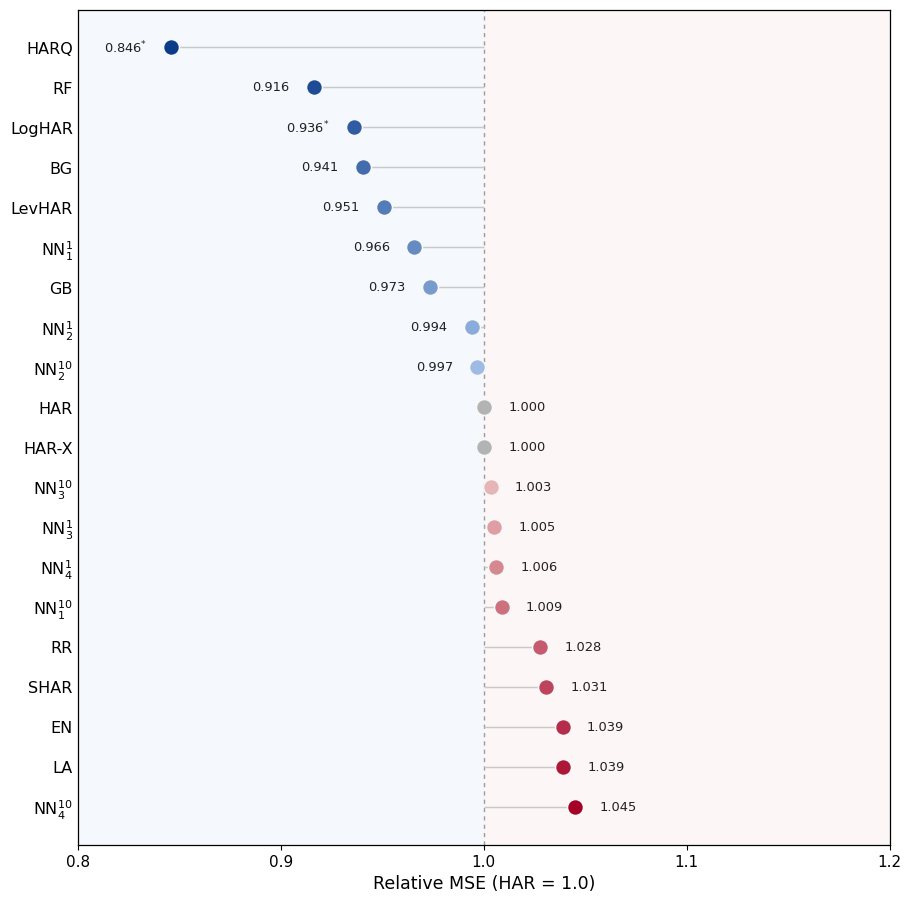

In [308]:
relative_to_har = pd.Series({model: mse / mse_by_model["HAR"] for model, mse in mse_by_model.items()})
relative_to_har = relative_to_har.loc[available_models].sort_values()


def hex_to_rgb(hex_color: str) -> np.ndarray:
    hex_color = hex_color.lstrip("#")
    return np.array([int(hex_color[i:i + 2], 16) for i in (0, 2, 4)], dtype=float)


def rgb_to_hex(rgb: np.ndarray) -> str:
    rgb = np.clip(np.round(rgb), 0, 255).astype(int)
    return "#%02x%02x%02x" % tuple(rgb)


def interpolate_hex(start_hex: str, end_hex: str, n: int) -> list[str]:
    if n <= 0:
        return []
    if n == 1:
        return [start_hex]
    start_rgb = hex_to_rgb(start_hex)
    end_rgb = hex_to_rgb(end_hex)
    weights = np.linspace(0.0, 1.0, n)
    return [rgb_to_hex((1 - weight) * start_rgb + weight * end_rgb) for weight in weights]


plot_label_map = {
    "HAR": "HAR",
    "HAR-X": "HAR-X",
    "LogHAR": "LogHAR",
    "LevHAR": "LevHAR",
    "SHAR": "SHAR",
    "HARQ": "HARQ",
    "RR": "RR",
    "LA": "LA",
    "EN": "EN",
    "BG": "BG",
    "RF": "RF",
    "GB": "GB",
    "NN1_best": r"$\mathrm{NN}_{1}^{1}$",
    "NN1_top10": r"$\mathrm{NN}_{1}^{10}$",
    "NN2_best": r"$\mathrm{NN}_{2}^{1}$",
    "NN2_top10": r"$\mathrm{NN}_{2}^{10}$",
    "NN3_best": r"$\mathrm{NN}_{3}^{1}$",
    "NN3_top10": r"$\mathrm{NN}_{3}^{10}$",
    "NN4_best": r"$\mathrm{NN}_{4}^{1}$",
    "NN4_top10": r"$\mathrm{NN}_{4}^{10}$",
}

plot_models = relative_to_har.index.tolist()
plot_values = relative_to_har.values
benchmark_models = [model for model in ["HAR", "HAR-X"] if model in plot_models]
left_models = [model for model in plot_models if model not in benchmark_models and relative_to_har[model] < 1.0]
right_models = [model for model in plot_models if model not in benchmark_models and relative_to_har[model] > 1.0]

point_color_map = {model: "#b3b3b3" for model in benchmark_models}
for model, color in zip(left_models, interpolate_hex("#0b3c8a", "#9dbbe5", len(left_models))):
    point_color_map[model] = color
for model, color in zip(right_models, interpolate_hex("#e6b5b5", "#a50026", len(right_models))):
    point_color_map[model] = color

x_min = 0.80
x_max = 1.20
y_step = 1.22
y_pos = np.arange(len(plot_models)) * y_step
y_labels = [plot_label_map.get(model, model) for model in plot_models]

fig, ax = plt.subplots(figsize=(11.6, 9.6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.axvspan(x_min, 1.0, color="#f5f8fc", zorder=0)
ax.axvspan(1.0, x_max, color="#fcf6f6", zorder=0)
ax.axvline(1.0, color="#9d9d9d", linestyle=(0, (3, 3)), linewidth=1.0, zorder=1)

for y, model, value in zip(y_pos, plot_models, plot_values):
    ax.hlines(y, 1.0, value, color="#c9c9c9", linewidth=1.05, zorder=1)
    ax.scatter(
        value,
        y,
        s=132,
        color=point_color_map[model],
        edgecolor="#f8f8f8",
        linewidth=1.1,
        zorder=3,
    )

    stars = "" if model == "HAR" else star_label(dm_pvalue_matrix.loc["HAR", model])
    label = rf"{value:.3f}$^{{{stars}}}$" if stars else f"{value:.3f}"
    offset = 0.012

    if value < 1.0:
        ax.text(value - offset, y, label, ha="right", va="center", fontsize=9.4, color="#222222", zorder=4)
    elif value > 1.0:
        ax.text(value + offset, y, label, ha="left", va="center", fontsize=9.4, color="#222222", zorder=4)
    else:
        ax.text(value + offset, y, label, ha="left", va="center", fontsize=9.4, color="#222222", zorder=4)

ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels, fontsize=11.5, fontweight="normal")
ax.invert_yaxis()
ax.set_xlim(x_min, x_max)
ax.set_xticks(np.arange(0.8, 1.21, 0.1))
ax.set_xlabel("Relative MSE (HAR = 1.0)", fontsize=12.5)
ax.tick_params(axis="x", labelsize=11.0)
ax.tick_params(axis="y", length=0)
ax.grid(False, axis="x")
ax.grid(False, axis="y")

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color("#000000")
    ax.spines[spine].set_linewidth(0.9)

plt.subplots_adjust(left=0.26, right=0.96, top=0.96, bottom=0.09)

export_path = Path("/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Figures/Results/MHAR_Dot_plot.pdf")
export_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(export_path, format="pdf", bbox_inches="tight")
print(f"Saved figure to: {export_path}")

plt.show()

**Notes:** The models are ordered from the lowest to the highest relative MSE against HAR. Dots to the left of `1.0` outperform the benchmark, while dots to the right underperform it. The asterisks next to each value correspond to the one-sided Diebold--Mariano test of the null of equal predictive accuracy against the alternative that the selected model improves on HAR.

## 8. Volatility Regime Performance

This section partitions the common evaluation sample into terciles based on the realized variance series `RV_actual`. Let $c_{1/3}$ and $c_{2/3}$ denote the empirical 33.3rd and 66.7th percentiles of `RV_actual`. The three volatility regimes are then defined as

$$
\text{Low}: RV_t \leq c_{1/3}, \qquad \text{Medium}: c_{1/3} < RV_t \leq c_{2/3}, \qquad \text{High}: RV_t > c_{2/3}.
$$

To express the same cutoffs in annualized standard-deviation units, we use

$$
\sigma_t^{\mathrm{ann}} = 100\sqrt{252 \cdot RV_t}.
$$

The code below reports the exact tercile boundaries in both realized-variance and annualized-standard-deviation terms, and then plots the relative MSE of each model against HAR within each regime. Each panel is sorted independently in ascending order from left to right, and each bar is annotated with the corresponding relative MSE rounded to two decimals. Values below `1.0` indicate that the model improves on HAR in that volatility segment.

Regime,RV_actual range,Annualized SD (%),Observations
Low,RV_actual <= 2.7613e-05,<= 8.34,366
Medium,2.7613e-05 < RV_actual <= 5.8877e-05,8.34 < SD <= 12.18,367
High,RV_actual > 5.8877e-05,> 12.18,366


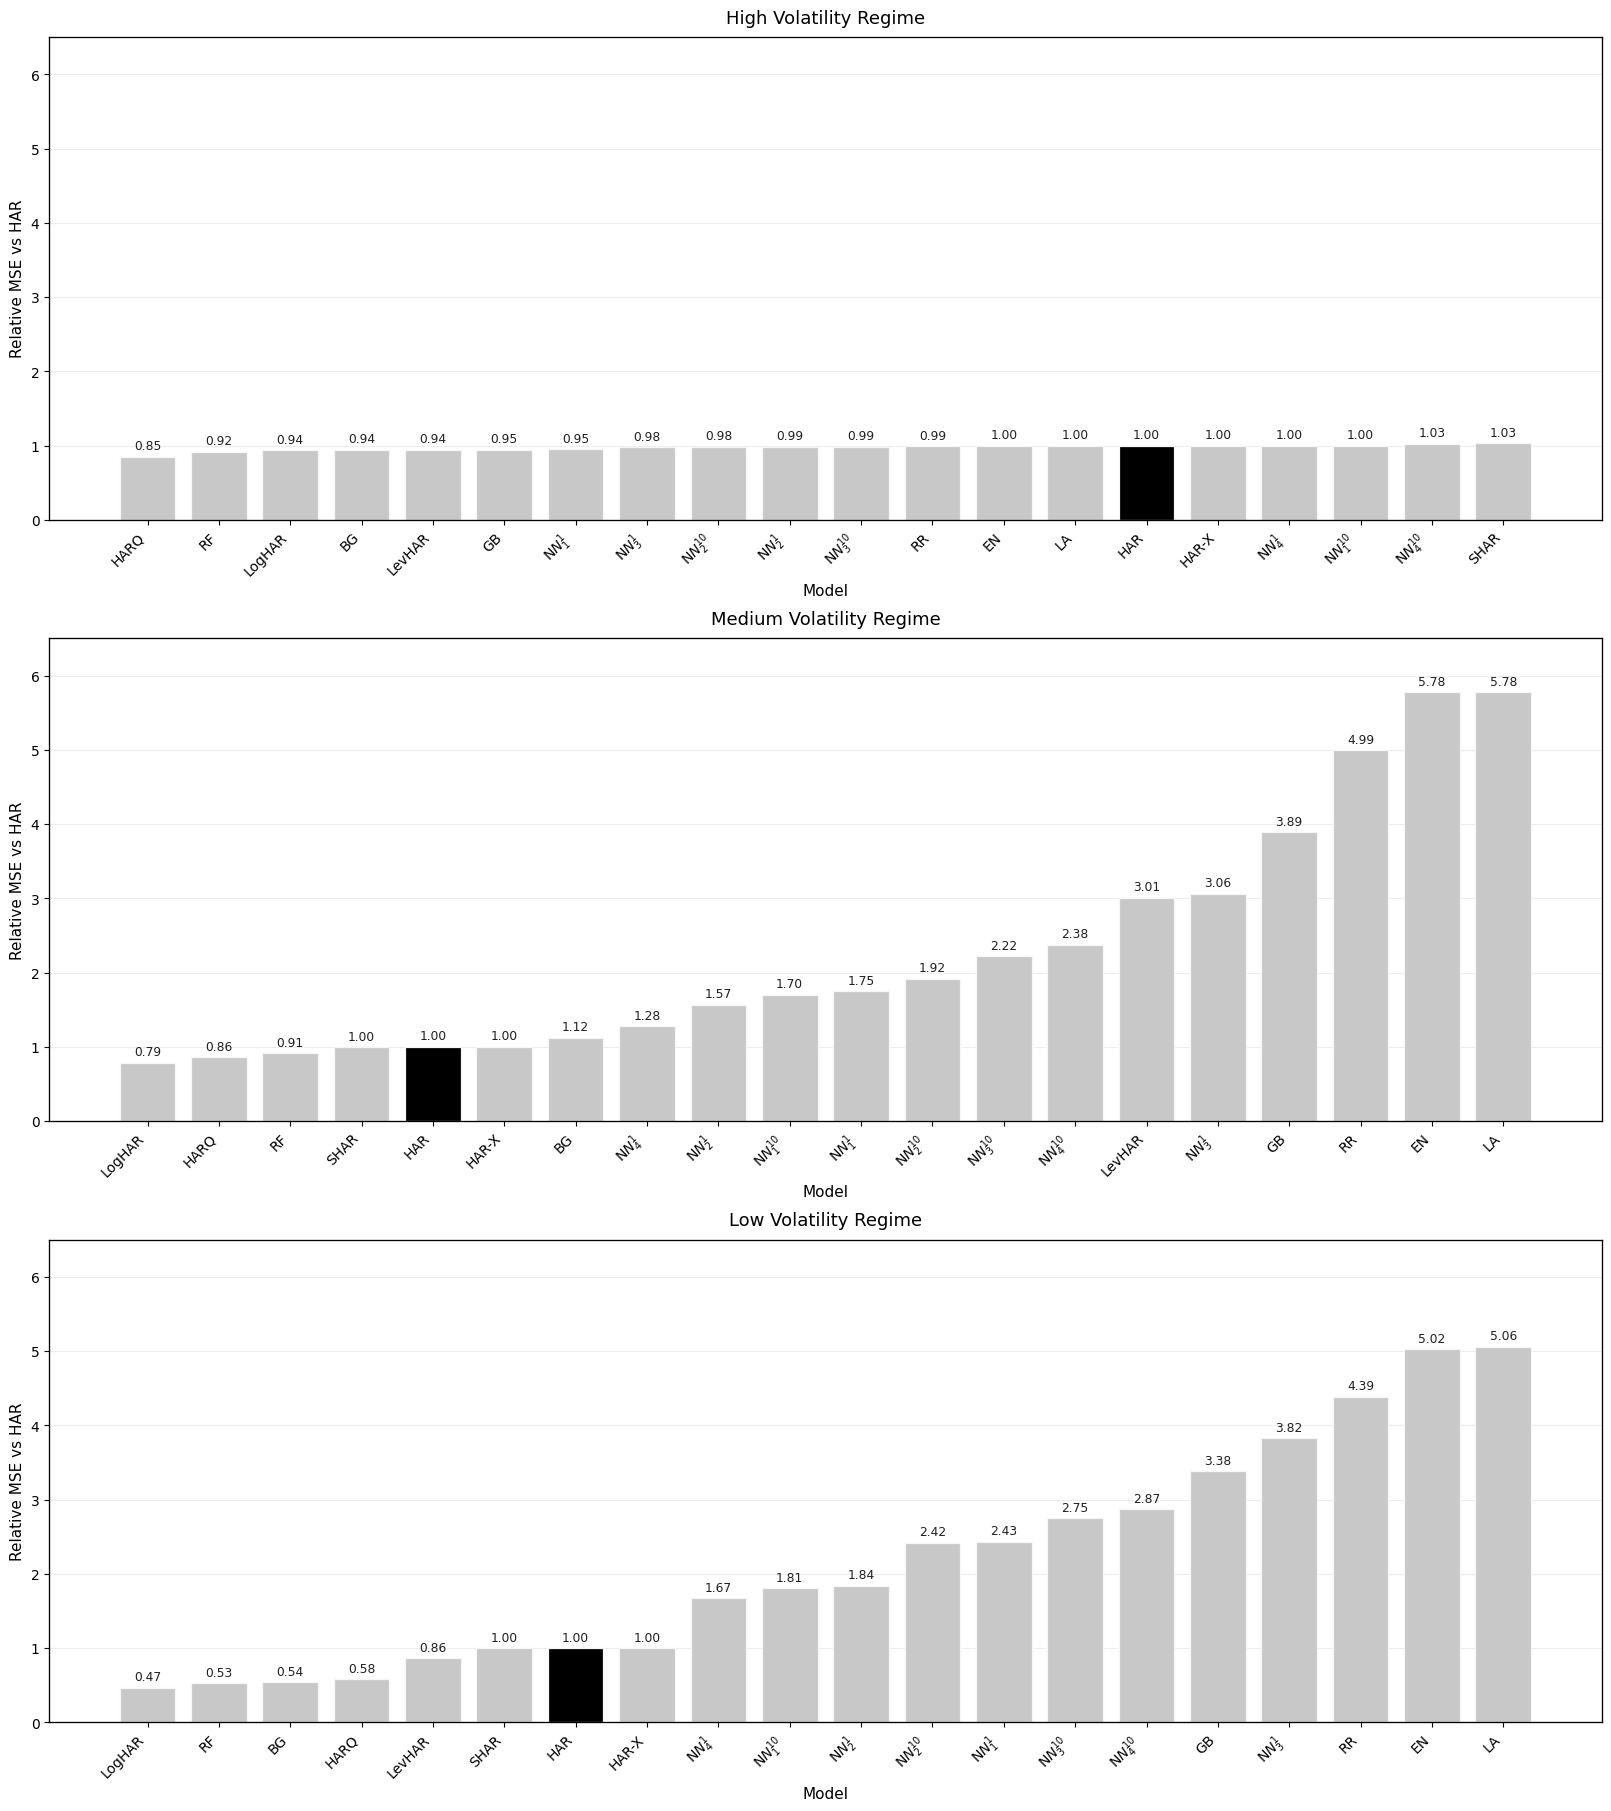

In [314]:
regime_label_map = {
    "HAR": "HAR",
    "HAR-X": "HAR-X",
    "LogHAR": "LogHAR",
    "LevHAR": "LevHAR",
    "SHAR": "SHAR",
    "HARQ": "HARQ",
    "RR": "RR",
    "LA": "LA",
    "EN": "EN",
    "BG": "BG",
    "RF": "RF",
    "GB": "GB",
    "NN1_best": r"N$N_{1}^{1}$",
    "NN1_top10": r"N$N_{1}^{10}$",
    "NN2_best": r"N$N_{2}^{1}$",
    "NN2_top10": r"N$N_{2}^{10}$",
    "NN3_best": r"N$N_{3}^{1}$",
    "NN3_top10": r"N$N_{3}^{10}$",
    "NN4_best": r"N$N_{4}^{1}$",
    "NN4_top10": r"N$N_{4}^{10}$",
}

tercile_cutoffs = actual.quantile([1 / 3, 2 / 3])
rv_cutoff_low_medium = float(tercile_cutoffs.loc[1 / 3])
rv_cutoff_medium_high = float(tercile_cutoffs.loc[2 / 3])
ann_sd_cutoff_low_medium = float(np.sqrt(rv_cutoff_low_medium * 252) * 100)
ann_sd_cutoff_medium_high = float(np.sqrt(rv_cutoff_medium_high * 252) * 100)

regime_masks = {
    "Low": actual <= rv_cutoff_low_medium,
    "Medium": (actual > rv_cutoff_low_medium) & (actual <= rv_cutoff_medium_high),
    "High": actual > rv_cutoff_medium_high,
}

regime_threshold_table = pd.DataFrame(
    [
        {
            "Regime": "Low",
            "RV_actual range": f"RV_actual <= {rv_cutoff_low_medium:.4e}",
            "Annualized SD (%)": f"<= {ann_sd_cutoff_low_medium:.2f}",
            "Observations": int(regime_masks["Low"].sum()),
        },
        {
            "Regime": "Medium",
            "RV_actual range": f"{rv_cutoff_low_medium:.4e} < RV_actual <= {rv_cutoff_medium_high:.4e}",
            "Annualized SD (%)": f"{ann_sd_cutoff_low_medium:.2f} < SD <= {ann_sd_cutoff_medium_high:.2f}",
            "Observations": int(regime_masks["Medium"].sum()),
        },
        {
            "Regime": "High",
            "RV_actual range": f"RV_actual > {rv_cutoff_medium_high:.4e}",
            "Annualized SD (%)": f"> {ann_sd_cutoff_medium_high:.2f}",
            "Observations": int(regime_masks["High"].sum()),
        },
    ]
)

regime_threshold_styler = (
    regime_threshold_table.style.hide(axis="index")
    .set_caption("Table: Tercile boundaries for the MHAR volatility-regime analysis")
    .set_table_styles(
        [
            {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold"), ("text-align", "left"), ("padding-bottom", "8px")]},
            {"selector": "thead th", "props": [("font-size", "12px"), ("text-align", "center"), ("border-bottom", "1px solid black"), ("padding", "6px")]},
            {"selector": "tbody td", "props": [("font-size", "12px"), ("text-align", "center"), ("padding", "6px")]},
            {"selector": "table", "props": [("border-collapse", "collapse"), ("width", "100%")]},
        ]
    )
)

display(regime_threshold_styler)

regime_relative_mse = {}
for regime, mask in regime_masks.items():
    actual_regime = actual.loc[mask]
    har_mse_regime = float(np.mean((actual_regime - forecast_panel.loc[mask, "HAR"]) ** 2))
    regime_relative_mse[regime] = {
        model: float(np.mean((actual_regime - forecast_panel.loc[mask, model]) ** 2)) / har_mse_regime
        for model in available_models
    }

regime_relative_mse = pd.DataFrame(regime_relative_mse).T

panel_order = ["High", "Medium", "Low"]
panel_color_map = {
    "High": "#C8C8C8",
    "Medium": "#C8C8C8",
    "Low": "#C8C8C8",
}
benchmark_color = "#000000"
global_y_min = 0.0
global_y_max = float(regime_relative_mse.max().max())
global_y_padding = max(0.06, 0.10 * global_y_max)
value_label_offset = max(0.015, 0.025 * global_y_max)

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(16, 18), constrained_layout=True)
fig.patch.set_facecolor("white")

for ax, regime in zip(axes, panel_order):
    ranked_values = regime_relative_mse.loc[regime].sort_values(kind="stable")
    display_labels = [regime_label_map.get(model, model) for model in ranked_values.index]
    bar_colors = [benchmark_color if model == "HAR" else panel_color_map[regime] for model in ranked_values.index]

    bar_container = ax.bar(
        display_labels,
        ranked_values.to_numpy(dtype=float),
        color=bar_colors,
        edgecolor="#F4F6F8",
        linewidth=0.9,
        width=0.78,
    )
    ax.bar_label(bar_container, labels=[f"{value:.2f}" for value in ranked_values], padding=3, fontsize=8.8, color="#1F1F1F")
    ax.set_title(f"{regime} Volatility Regime", fontsize=13, pad=10)
    ax.set_ylabel("Relative MSE vs HAR", fontsize=11)
    ax.set_xlabel("Model", fontsize=11)
    ax.grid(axis="y", alpha=0.22, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(axis="x", rotation=45, labelsize=10)
    for label in ax.get_xticklabels():
        label.set_ha("right")
    ax.set_ylim(global_y_min, global_y_max + global_y_padding + value_label_offset)
    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color("#000000")
        ax.spines[spine].set_linewidth(0.95)

plt.show()

## 9. Appendix Table: Loss Function Summary

The table below reports the out-of-sample MSE, QLIKE, MAE, and RMSE for every MHAR model on the common evaluation sample. To improve readability, MSE is reported in units of $10^{-8}$, MAE and RMSE are reported in units of $10^{-4}$, and QLIKE is reported in its native (dimensionless) unit. All values are rounded to two decimals. Models appear in the order in which they were loaded in section 2 and the table is intentionally not sorted, so that it can serve as a static reference table in the thesis appendix.

In [ ]:
appendix_display_map = {
    "HAR": "HAR",
    "HAR-X": "HAR-X",
    "LogHAR": "LogHAR",
    "LevHAR": "LevHAR",
    "SHAR": "SHAR",
    "HARQ": "HARQ",
    "RR": "RR",
    "LA": "LA",
    "EN": "EN",
    "BG": "BG",
    "RF": "RF",
    "GB": "GB",
    "NN1_best": "$\\mathbf{NN}_{1}^{1}$",
    "NN1_top10": "$\\mathbf{NN}_{1}^{10}$",
    "NN2_best": "$\\mathbf{NN}_{2}^{1}$",
    "NN2_top10": "$\\mathbf{NN}_{2}^{10}$",
    "NN3_best": "$\\mathbf{NN}_{3}^{1}$",
    "NN3_top10": "$\\mathbf{NN}_{3}^{10}$",
    "NN4_best": "$\\mathbf{NN}_{4}^{1}$",
    "NN4_top10": "$\\mathbf{NN}_{4}^{10}$",
}

appendix_loss_table = pd.DataFrame(index=available_models)
appendix_loss_table["MSE (10^-8)"] = [loss_summary.loc[model, "MSE"] * 1e8 for model in available_models]
appendix_loss_table["QLIKE"] = [loss_summary.loc[model, "QLIKE"] for model in available_models]
appendix_loss_table["MAE (10^-4)"] = [loss_summary.loc[model, "MAE"] * 1e4 for model in available_models]
appendix_loss_table["RMSE (10^-4)"] = [loss_summary.loc[model, "RMSE"] * 1e4 for model in available_models]

appendix_loss_table_display = appendix_loss_table.rename(index=appendix_display_map)

appendix_loss_styler = (
    appendix_loss_table_display.style.format(
        {
            "MSE (10^-8)": "{:.2f}",
            "QLIKE": "{:.2f}",
            "MAE (10^-4)": "{:.2f}",
            "RMSE (10^-4)": "{:.2f}",
        }
    )
    .set_caption("Table: Out-of-sample loss-function summary for the MHAR feature set")
    .set_table_styles(
        [
            {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold"), ("text-align", "left"), ("padding-bottom", "8px")]},
            {"selector": "thead th", "props": [("font-size", "12px"), ("text-align", "center"), ("border-bottom", "1px solid black"), ("padding", "6px")]},
            {"selector": "tbody th", "props": [("font-size", "12px"), ("text-align", "left"), ("padding", "6px"), ("font-weight", "bold")]},
            {"selector": "tbody td", "props": [("font-size", "12px"), ("text-align", "center"), ("padding", "6px")]},
            {"selector": "table", "props": [("border-collapse", "collapse"), ("width", "100%")]},
        ]
    )
)

display(appendix_loss_styler)